# Width-Scaling SGD Experiments with Causal Attention, d16 Excluded

Same task, optimizer, and width sweep as `colab_width_scaling_sgd_exclude_d8_d16.ipynb`,
with `use_attention: True` selecting the transformer architecture instead of the plain
residual MLP.

The transformer treats the problem as next-position prediction. The sequence is the 16
input bits followed by the target parities in binary-tree order (all degree-2 parities,
then degree-4, then degree-8). The last input position predicts the first degree-2
parity, the next position predicts the second, and so on. Every position — input bits
and intermediate answers alike — owns a learnable embedding vector that the value at
that position scales. Each of the `L` blocks is causal self-attention with a residual
connection followed by the same MLP block the residual net uses (also residual, with
`use_post_activation_linear` optional). There is no layer normalization. The unembedding
is a single position-independent `N -> 1` map.

Training is teacher-forced on the true parities. Test-time evaluation is autoregressive:
only the input bits are given and each prediction is fed back into the next position.

## Setup

Mount Google Drive, clone the public repo, install it in editable mode, and define the run/plot directories.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/labofdoubt/feature-learning-parity-task.git"
REPO_DIR = Path("/content/feature-learning-parity-task")

DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_exclude_d16_attention_fixed_emb")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
!rm -rf "$REPO_DIR"
!git clone "$GITHUB_REPO_URL" "$REPO_DIR"
%cd "$REPO_DIR"
!pip install -e .

Cloning into '/content/feature-learning-parity-task'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (261/261), done.
remote: Compressing objects: 100% (182/182), done.
remote: Total 261 (delta 183), reused 157 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (261/261), 9.71 MiB | 21.86 MiB/s, done.
Resolving deltas: 100% (183/183), done.
/content/feature-learning-parity-task
Obtaining file:///content/feature-learning-parity-task
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for parity-net (pyproject.toml) ... done
  Created wheel for parity-net: filename=parity_net-0.1.0-0.editable-py3-none-any.whl size=3070 sha256=4269249c0396def6ce8af4512e04dfadf1502f5e044e55c02225c1154c5e6d30
  Stored in directory: /tmp/pip-ephem-wheel-cache-bm5i058j/wheels/a2/05/6b/5da726f55833c1e289

## Train Width Sweep

One config per width, identical to the residual-MLP sweep except for `use_attention: True`
and `num_heads`. Existing final checkpoints are skipped unless `FORCE_RETRAIN = True`.


In [3]:
from pathlib import Path

import yaml

from parity_net.config import load_config
from parity_net.train import train

WIDTHS = [1024]
FORCE_RETRAIN = True


def make_config(N: int, output_dir: Path) -> dict:
    return {
        "model": {
            "input_dim": 16,
            "relevant_dim": 8,
            "N": N,
            "L": 3,
            "activation": "half-tanh",
            "use_readout_barrier": False,
            "embedding_weight_variance": 1.0,
            "freeze_embedding": False,
            "hidden_weight_variance": 1.0 / N,
            "readout_weight_variance": 1.0 / N,
            "use_layerwise_readouts": False,
            "use_post_activation_linear": True,
            "bias": False,
            "use_attention": True,
            "num_heads": 1,
            "attention_logit_scale": "1/sqrt(d)",
            "autoregressive_feedback": "raw",
            "use_kv_cache": True,
        },
        "task": {
            "input_dim": 16,
            "relevant_dim": 8,
            # "exclude_targets": ["d4", "d8", "d16"],
            "exclude_targets": ["d16"]
        },
        "training": {
            "num_steps": 10_000,
            "train_samples": 1024,
            "test_samples": 100_000,
            "batch_size": 512,
            "seed": 0,
            "device": "cuda",
            # Storage precision for every tensor: "float32" or "float64".
            "dtype": "float32",
            # Matmul precision. "highest" = true float32 (PyTorch's default, what every
            # run so far used). "high" = TF32: matmul inputs keep a 10-bit mantissa,
            # accumulation stays float32, and the tensor cores do the work - on Ampere
            # and later that is several times faster. "medium" also allows bfloat16
            # inputs. Only matmuls change; optimizer, loss and elementwise stay float32.
            "matmul_precision": "high",
            # Full test evaluation + a metrics.csv row. Coinciding with
            # checkpoint_every no longer evaluates twice.
            "progress_every": 100,
            "validate_every": 1_000,
            "checkpoint_every": 1_000,
            "output_dir": str(output_dir),
            "barrier_c": None,
            "barrier_lambda": 10.0,
            "optimizer": {
                "name": "sgd",
                "lr": 1e-3,
                "lr_embedding": None,
                "lr_hidden": None,
                "lr_readout": None,
                "weight_decay": 1e-3,
                "wd_embedding": None,
                "wd_hidden": None,
                "wd_readout": None,
                "momentum": 0.9,
                "betas": [0.9, 0.999],
            },
        },
    }

def make_config_mup(N: int, output_dir: Path) -> dict:
    config = make_config(N, output_dir)
    optimizer = config["training"]["optimizer"]
    base_lr = optimizer["lr"]
    base_wd = optimizer["weight_decay"]
    config["model"]["readout_weight_variance"] = 1 / N**2
    # muP keeps query-key logits Theta(1) as head_dim grows with width.
    config["model"]["attention_logit_scale"] = "1/d"

    optimizer["lr_embedding"] = base_lr * N / 256
    optimizer["lr_hidden"] = base_lr
    optimizer["lr_readout"] = base_lr * 256 / N

    optimizer["wd_embedding"] = base_wd * 256 / N
    optimizer["wd_hidden"] = base_wd
    optimizer["wd_readout"] = base_wd * N / 256
    return config


CONFIG_FACTORY = make_config_mup  # Change to make_config for the unscaled sweep.

In [ ]:
config_paths = {}
for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    run_dir.mkdir(parents=True, exist_ok=True)
    config_path = run_dir / "config.yaml"
    final_checkpoint = run_dir / "checkpoints" / "final.pt"

    if final_checkpoint.exists() and not FORCE_RETRAIN:
        config_paths[N] = config_path
        print(
            f"N={N}: final checkpoint exists, skipping training: {final_checkpoint}. "
            "Set FORCE_RETRAIN=True or choose a new DRIVE_ROOT to train with changed config values."
        )
        continue

    config = CONFIG_FACTORY(N, run_dir)
    with config_path.open("w") as f:
        yaml.safe_dump(config, f, sort_keys=False)
    config_paths[N] = config_path

    print(f"N={N}: training with {config_path}")
    final_path = train(load_config(config_path))
    print(f"N={N}: saved final checkpoint to {final_path}")

N=1024: training with /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_exclude_d16_attention_fixed_emb/runs/N_1024/config.yaml


/content/feature-learning-parity-task/parity_net/data.py:313: RuntimeWarning: Requested 100000 unique inputs, but input_dim=16 gives only 65536 possible inputs. Truncating dataset to 65536 unique samples.
  x = sample_unique_inputs(n, input_dim, device).to(dtype=dtype)
/tmp/ipykernel_59605/1653051944.py:22: RuntimeWarning: The saved test set covers the full input space, so training samples cannot be drawn while avoiding every test input. Training will continue with ordinary random samples, and train/test overlap is possible.
  final_path = train(load_config(config_path))


training:   0%|          | 0/10000 [00:00<?, ?step/s]

step 100: train_mse=0.8967 loss=0.8967 elapsed=8.8s
step 200: train_mse=0.6764 loss=0.6764 elapsed=17.5s
step 300: train_mse=0.4288 loss=0.4288 elapsed=26.4s
step 400: train_mse=0.2635 loss=0.2635 elapsed=35.5s
step 500: train_mse=0.1629 loss=0.1629 elapsed=44.6s
step 600: train_mse=0.1045 loss=0.1045 elapsed=53.7s
step 700: train_mse=0.05358 loss=0.05358 elapsed=62.6s


## Train/Test Curves

Read `metrics.csv` from each run, save one plot per width, and save combined train/test
plots across widths. `test_mse` is autoregressive.

In [10]:
RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

WIDTHS = [2048]

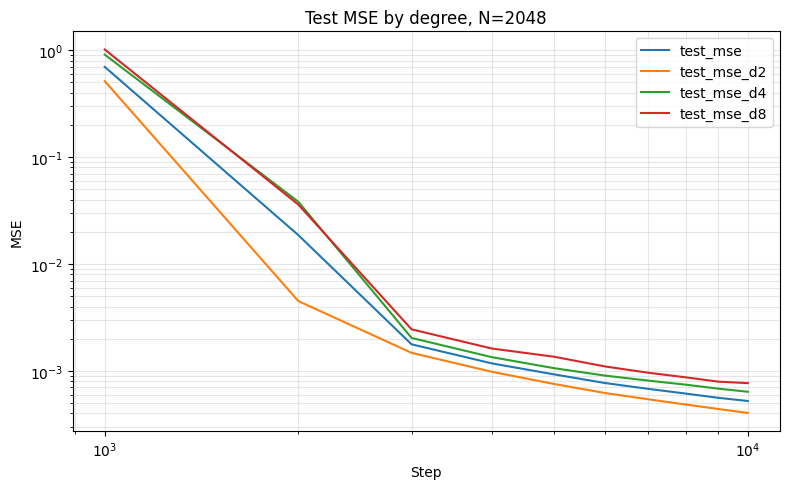

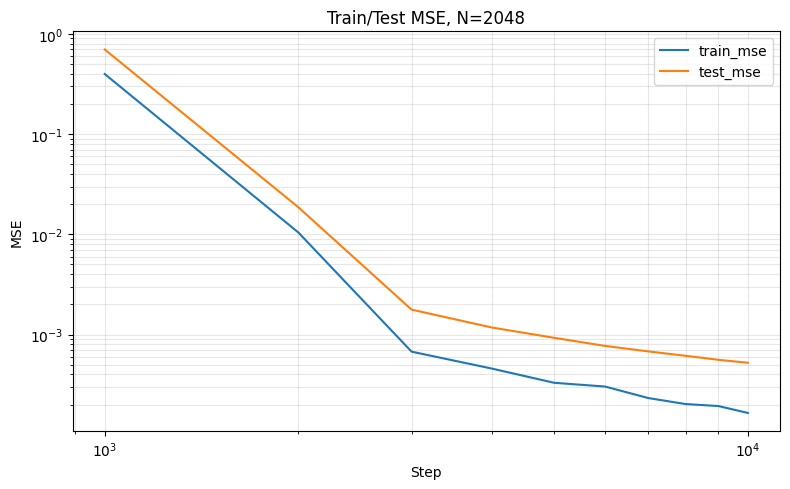

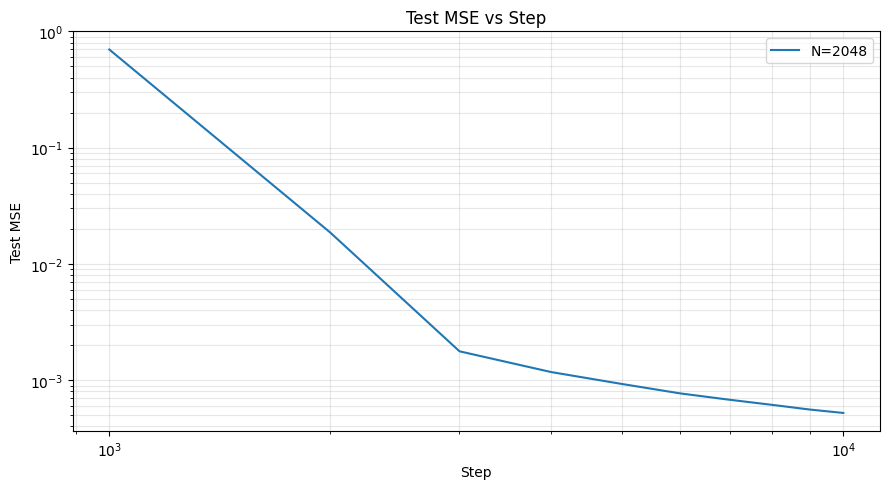

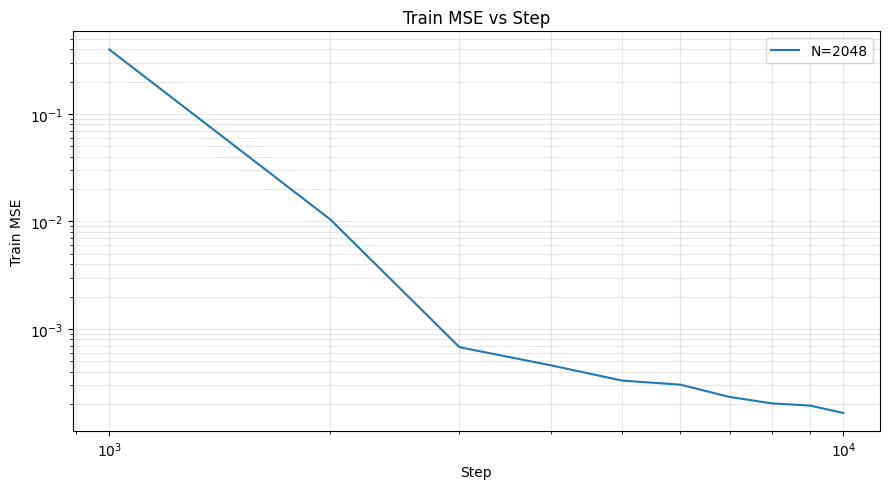

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

USE_LOG_MSE_AXIS = True
USE_LOG_STEP_AXIS = True
TEST_MSE_COLUMNS = ["test_mse", "test_mse_d2", "test_mse_d4", "test_mse_d8", "test_mse_d16"]


def axis_has_positive_data(ax, axis):
    for line in ax.lines:
        values = line.get_xdata() if axis == "x" else line.get_ydata()
        if len(values) and pd.Series(values).dropna().gt(0).any():
            return True
    return False


def maybe_log_y(ax):
    if USE_LOG_MSE_AXIS and axis_has_positive_data(ax, "y"):
        ax.set_yscale("log")


def maybe_log_x(ax):
    if USE_LOG_STEP_AXIS and axis_has_positive_data(ax, "x"):
        ax.set_xscale("log")


metrics_by_width = {}
for N in WIDTHS:
    metrics_path = RUNS_DIR / f"N_{N}" / "metrics.csv"
    if not metrics_path.exists():
        print(f"N={N}: missing {metrics_path}")
        continue
    df = pd.read_csv(metrics_path)
    metrics_by_width[N] = df

    fig, ax = plt.subplots(figsize=(8, 5))
    for column in TEST_MSE_COLUMNS:
        if column in df.columns:
            ax.plot(df["step"], df[column], label=column)
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Test MSE by degree, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"test_mse_by_degree_N_{N}.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["train_mse"], label="train_mse")
    ax.plot(df["step"], df["test_mse"], label="test_mse")
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Train/Test MSE, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"train_test_mse_N_{N}.png", dpi=150)
    plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["test_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "test_mse_by_width.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["train_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Train MSE")
ax.set_title("Train MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "train_mse_by_width.png", dpi=150)
plt.show()